In [21]:
import pandas as pd
import os
os.chdir("D:\loan prediction")

# Load dataset
df = pd.read_csv("loan_data.csv")   # change to your filename


<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:3: SyntaxWarning: invalid escape sequence '\l'
C:\Users\tejas\AppData\Local\Temp\ipykernel_25580\1737762256.py:3: SyntaxWarning: invalid escape sequence '\l'
  os.chdir("D:\loan prediction")


In [22]:
display(df.head())


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [23]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [24]:
display(df.describe())


,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [25]:
display(df.describe(include='object'))


,person_gender,person_education,person_home_ownership,loan_intent,previous_loan_defaults_on_file
count,45000,45000,45000,45000,45000
unique,2,5,4,6,2
top,male,Bachelor,RENT,EDUCATION,Yes
freq,24841,13399,23443,9153,22858


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load
df = pd.read_csv("loan_data.csv")

# Columns we will inspect
cols = ['person_income', 'loan_amnt']

# Make full copies of original columns so we can compare
for c in cols:
    df[f"{c}_orig"] = df[c].copy()


#Outlier detection function + report (before)

In [27]:
def iqr_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

def outlier_count(series):
    lower, upper = iqr_bounds(series)
    return ((series < lower) | (series > upper)).sum()

# Print outlier counts before capping
print("Outlier counts BEFORE capping:")
for c in cols:
    cnt = outlier_count(df[c])
    total = df.shape[0]
    print(f" {c}: {cnt} outliers  ({cnt/total*100:.2f}%)")


Outlier counts BEFORE capping:
 person_income: 2218 outliers  (4.93%)
 loan_amnt: 2348 outliers  (5.22%)


#Plot BEFORE (boxplot + histogram)

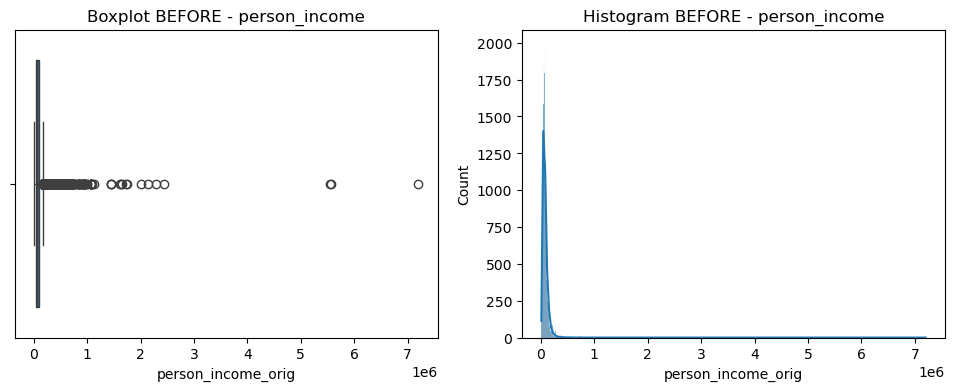

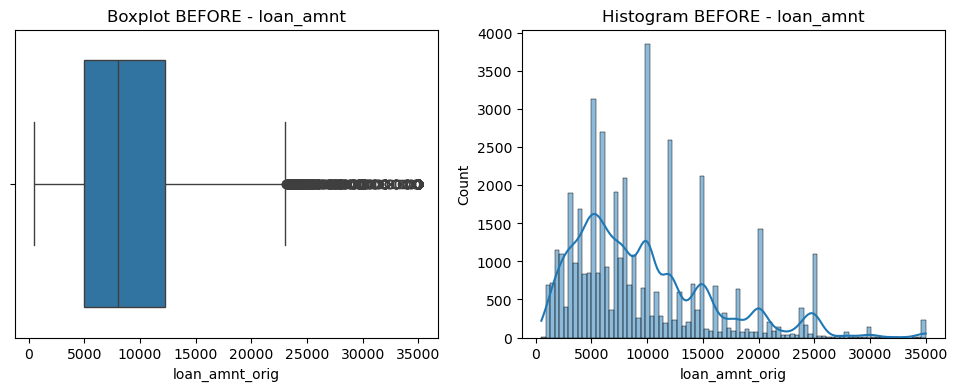

In [28]:
for c in cols:
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    sns.boxplot(x=df[f"{c}_orig"])
    plt.title(f"Boxplot BEFORE - {c}")

    plt.subplot(1,2,2)
    sns.histplot(df[f"{c}_orig"], kde=True)
    plt.title(f"Histogram BEFORE - {c}")

    plt.show()


#Define and apply capping function

In [29]:
def cap_outliers_inplace(df, col):
    lower, upper = iqr_bounds(df[col])
    df[col] = df[col].clip(lower, upper)
    return lower, upper

# Apply capping and record bounds used
bounds = {}
for c in cols:
    bounds[c] = cap_outliers_inplace(df, c)
    print(f"Capped {c} to bounds {bounds[c]}")


Capped person_income to bounds (-25673.875, 168667.125)
Capped loan_amnt to bounds (-5855.875, 23093.125)


#Outlier counts AFTER capping

In [30]:
print("Outlier counts AFTER capping:")
for c in cols:
    cnt = outlier_count(df[c])
    total = df.shape[0]
    print(f" {c}: {cnt} outliers  ({cnt/total*100:.2f}%)")


Outlier counts AFTER capping:
 person_income: 0 outliers  (0.00%)
 loan_amnt: 0 outliers  (0.00%)


#Plot AFTER (boxplot + histogram)

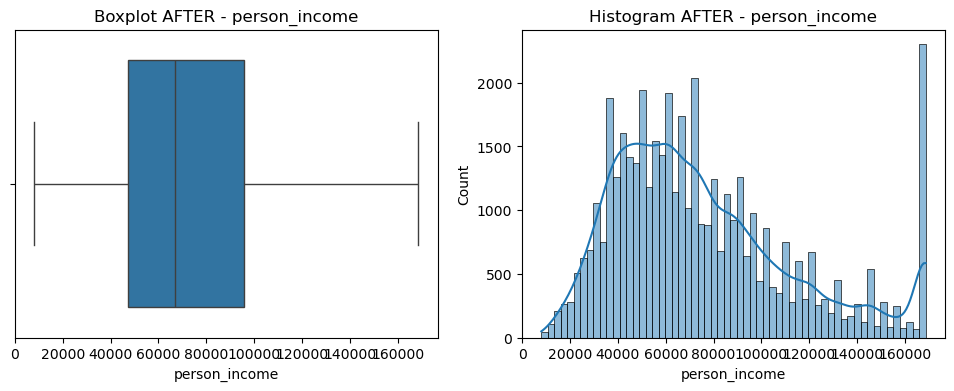

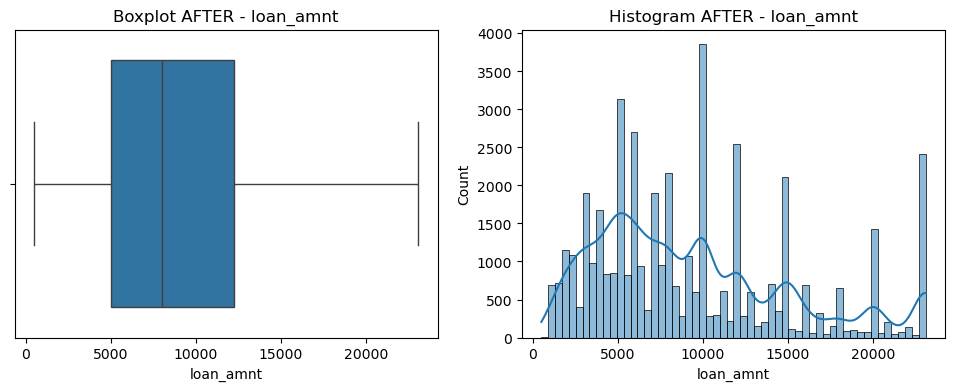

In [31]:
for c in cols:
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    sns.boxplot(x=df[c])
    plt.title(f"Boxplot AFTER - {c}")

    plt.subplot(1,2,2)
    sns.histplot(df[c], kde=True)
    plt.title(f"Histogram AFTER - {c}")

    plt.show()


#Bar chart: number of outliers before vs after

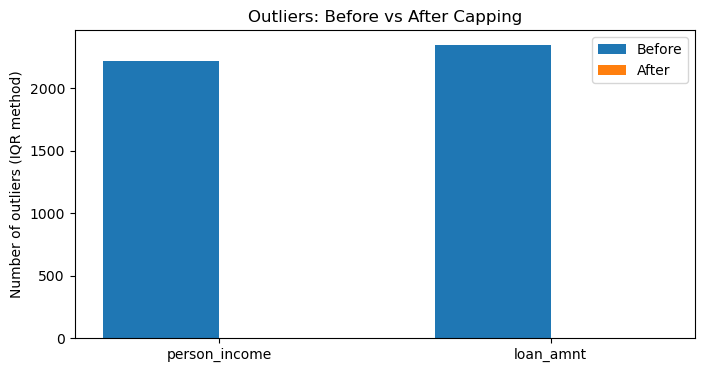

In [32]:
before_counts = []
after_counts = []
for c in cols:
    before_counts.append(outlier_count(df[f"{c}_orig"]))
    after_counts.append(outlier_count(df[c]))

x = np.arange(len(cols))
width = 0.35

fig, ax = plt.subplots(figsize=(8,4))
ax.bar(x - width/2, before_counts, width, label='Before')
ax.bar(x + width/2, after_counts, width, label='After')
ax.set_xticks(x)
ax.set_xticklabels(cols)
ax.set_ylabel("Number of outliers (IQR method)")
ax.set_title("Outliers: Before vs After Capping")
ax.legend()
plt.show()


In [33]:
# ============================
# BINARY ENCODING (Yes/No → 0/1)
# ============================
df["previous_loan_defaults_on_file"] = df["previous_loan_defaults_on_file"].map({
    "No": 0,
    "Yes": 1,
    False: 0,
    True: 1
}).astype(int)

# ============================
# ONE-HOT ENCODING (0/1 columns)
# ============================
cat_cols = [
    "person_gender",
    "person_education",
    "person_home_ownership",
    "loan_intent"
]

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# ============================
# ENSURE ALL BOOLEAN COLUMNS BECOME 0/1
# ============================
for col in df.columns:
    if df[col].dtype == "bool":
        df[col] = df[col].astype(int)


In [34]:
df.head()


,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,...,person_education_High School,person_education_Master,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22.0,71948.0,0,23093.125,16.02,0.49,3.0,561,0,1,...,0,1,0,0,1,0,0,0,1,0
1,21.0,12282.0,0,1000.000,11.14,0.08,2.0,504,1,0,...,1,0,0,1,0,1,0,0,0,0
2,25.0,12438.0,3,5500.000,12.87,0.44,3.0,635,0,1,...,1,0,0,0,0,0,0,1,0,0
3,23.0,79753.0,0,23093.125,15.23,0.44,2.0,675,0,1,...,0,0,0,0,1,0,0,1,0,0
4,24.0,66135.0,1,23093.125,14.27,0.53,4.0,586,0,1,...,0,1,0,0,1,0,0,1,0,0


In [35]:
# After ALL preprocessing steps
df.to_csv("processed_loan_data.csv", index=False)

print("Saved processed_loan_data.csv successfully!")


Saved processed_loan_data.csv successfully!


In [36]:
# ============================
# FEATURE ENGINEERING
# ============================

# 1. Approximate EMI (based on interest burden)
df["approx_emi"] = df["loan_amnt"] * (df["loan_int_rate"] / 100)

# 2. Balance income after paying interest
df["balance_income"] = df["person_income"] - df["approx_emi"]

# 3. Debt-to-Income Ratio (DTI)
df["dti"] = df["loan_amnt"] / (df["person_income"] + 1)

# 4. Credit age relative to person's age
df["credit_age_ratio"] = df["cb_person_cred_hist_length"] / (df["person_age"] + 1)

# 5. Income per year of experience
df["income_exp_ratio"] = df["person_income"] / (df["person_emp_exp"] + 1)

# 6. Log transforms (optional but powerful)
df["log_person_income"] = np.log1p(df["person_income"])
df["log_loan_amnt"] = np.log1p(df["loan_amnt"])


In [37]:
df.to_csv("processed_loan_data.csv", index=False)

#Train–Test Split

In [38]:
from sklearn.model_selection import train_test_split

# Load the processed dataset
df = pd.read_csv("processed_loan_data.csv")

# -----------------------------
# 1. Separate features and target
# -----------------------------
X = df.drop("loan_status", axis=1)   # all features
y = df["loan_status"]                # target (0/1)

# -----------------------------
# 2. Train-Test Split (STRATIFIED)
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y     # keeps class balance same in train & test
)

# -----------------------------
# 3. Confirm split shapes
# -----------------------------
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nClass distribution in training set:")
print(y_train.value_counts(normalize=True))

print("\nClass distribution in test set:")
print(y_test.value_counts(normalize=True))

X_train shape: (36000, 31)
X_test shape: (9000, 31)
y_train shape: (36000,)
y_test shape: (9000,)

Class distribution in training set:
loan_status
0    0.777778
1    0.222222
Name: proportion, dtype: float64

Class distribution in test set:
loan_status
0    0.777778
1    0.222222
Name: proportion, dtype: float64


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

results = []
models = {}

# CM AND ROC SIDE BY SIDE
def plot_cm_and_roc(y_true, y_pred, y_prob, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # ---------------- Confusion Matrix ----------------
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title(f"{title} - Confusion Matrix")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")

    # ---------------- ROC Curve ----------------
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    axes[1].plot([0, 1], [0, 1], 'k--')
    axes[1].set_title(f"{title} - ROC Curve")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].legend(loc="lower right")

    plt.tight_layout()
    plt.show()


#K-nearest neighbour


--- KNN Model ---
Accuracy: 0.8277777777777777
F1 Score: 0.5545977011494253
ROC-AUC: 0.80311575


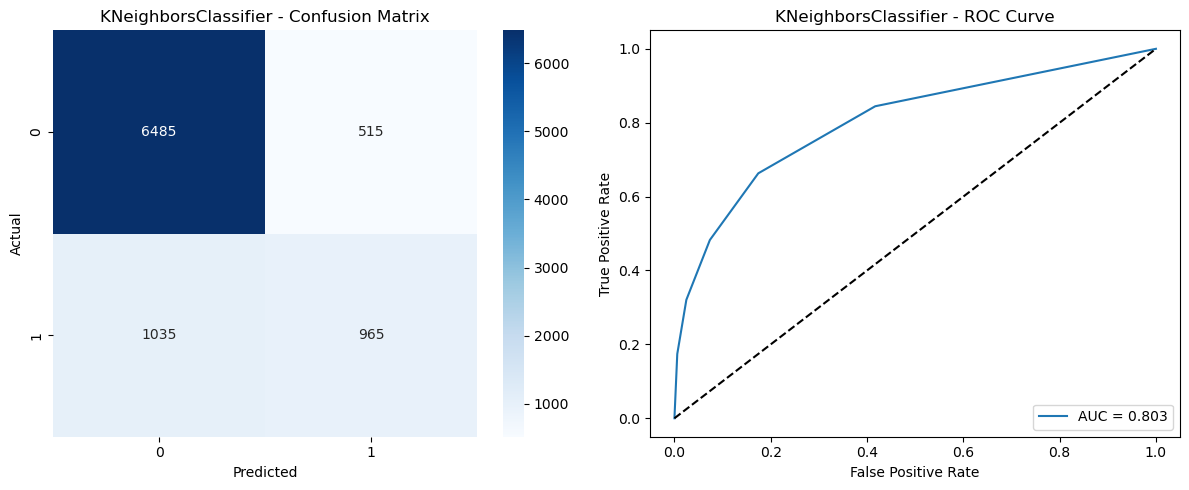

In [40]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

print("\n--- KNN Model ---")

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
y_prob = knn.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
plot_cm_and_roc(y_test , y_pred , y_prob , "KNeighborsClassifier")

results.append({
    "Model": "KNN",
    "Accuracy": accuracy_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC_AUC": roc_auc_score(y_test, y_prob)
})
models["KNN"] = knn


#decision tree


--- Decision Tree Model ---
Accuracy: 0.8996666666666666
F1 Score: 0.7752053771471247
ROC-AUC: 0.8563928571428571


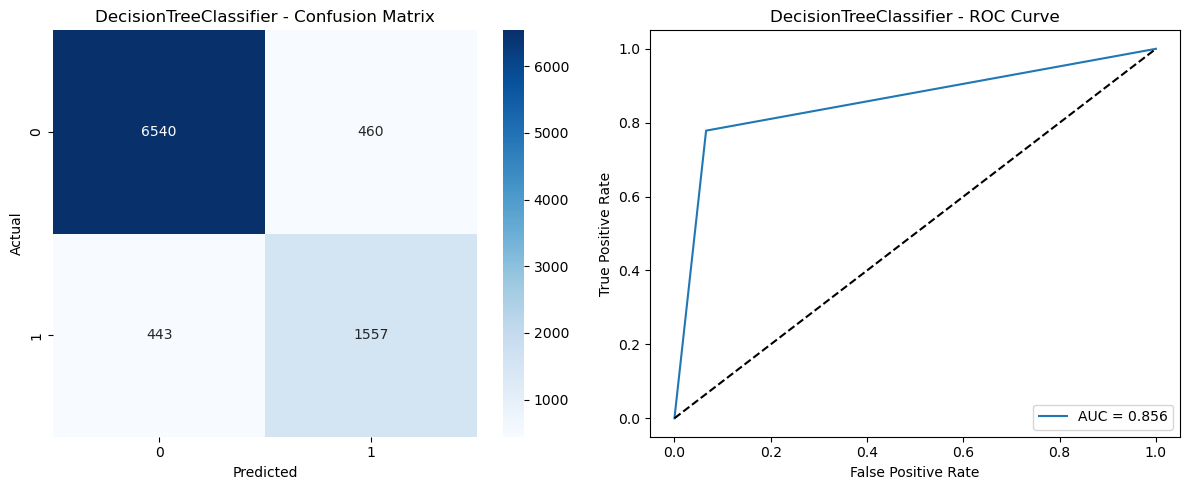

In [41]:
from sklearn.tree import DecisionTreeClassifier

print("\n--- Decision Tree Model ---")

dt = DecisionTreeClassifier(max_depth=None, random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)
y_prob = dt.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
plot_cm_and_roc(y_test , y_pred , y_prob , "DecisionTreeClassifier")

results.append({
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC_AUC": roc_auc_score(y_test, y_prob)
})
models["Decision Tree"] = dt



#random forest


--- Random Forest Model ---
Accuracy: 0.9368888888888889
F1 Score: 0.8482095136290754
ROC-AUC: 0.9787648214285714


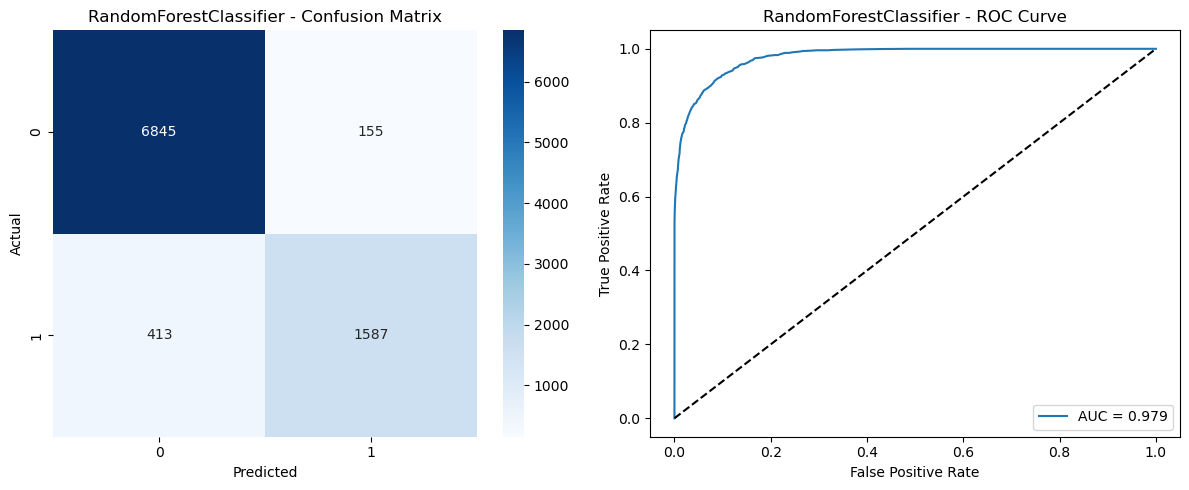

In [42]:
from sklearn.ensemble import RandomForestClassifier

print("\n--- Random Forest Model ---")

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
plot_cm_and_roc(y_test , y_pred , y_prob , "RandomForestClassifier")

results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC_AUC": roc_auc_score(y_test, y_prob)
})
models["Random Forest"] = rf



#gradient boosting


--- Gradient Boosting Model ---
Accuracy: 0.9232222222222223
F1 Score: 0.8147949611364246
ROC-AUC: 0.97195275


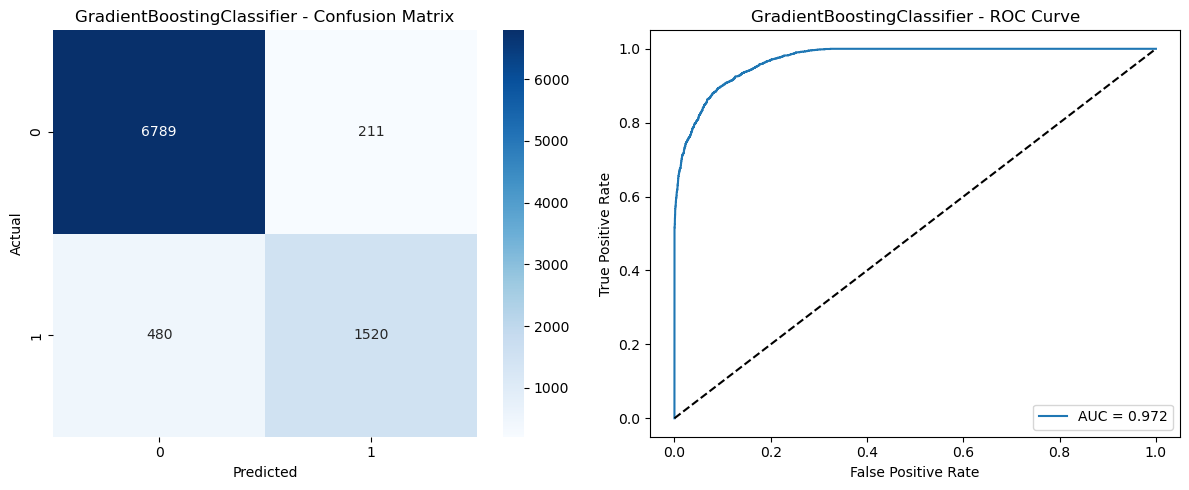

In [43]:
from sklearn.ensemble import GradientBoostingClassifier

print("\n--- Gradient Boosting Model ---")

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

y_pred = gb.predict(X_test)
y_prob = gb.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
plot_cm_and_roc(y_test , y_pred , y_prob , "GradientBoostingClassifier")

results.append({
    "Model": "Gradient Boosting",
    "Accuracy": accuracy_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC_AUC": roc_auc_score(y_test, y_prob)
})
models["Gradient Boosting"] = gb




--- XGBoost Model ---
Accuracy: 0.9324444444444444
F1 Score: 0.8382118147951038
ROC-AUC: 0.9764429285714287


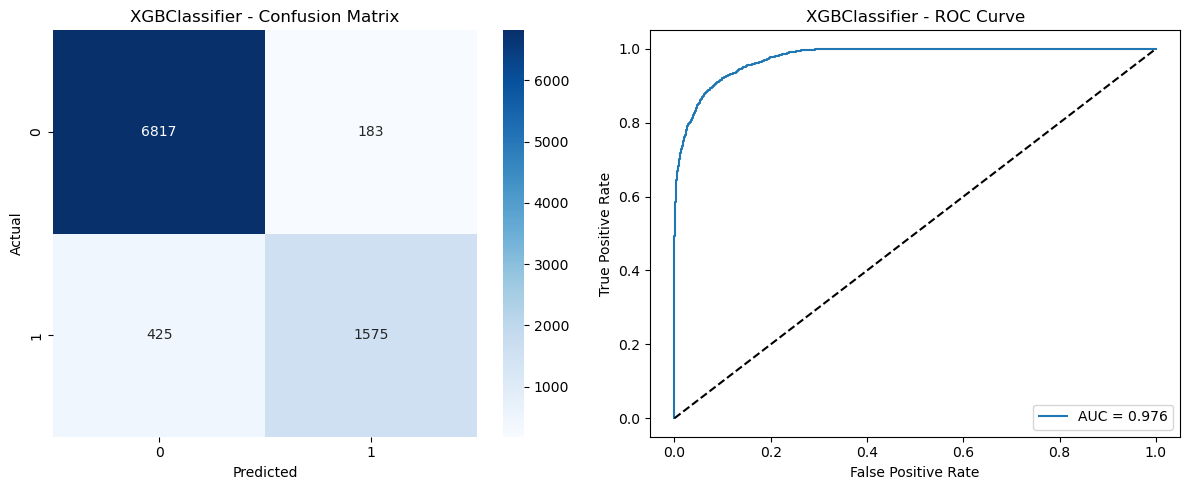

In [44]:
from xgboost import XGBClassifier

print("\n--- XGBoost Model ---")

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
plot_cm_and_roc(y_test,y_pred , y_prob , "XGBClassifier")

results.append({
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC_AUC": roc_auc_score(y_test, y_prob)
})
models["XGBoost"] = xgb


#Naive bayes



--- Naive Bayes Model ---
Accuracy: 0.7937777777777778
F1 Score: 0.5766423357664233
ROC-AUC: 0.8075447142857143


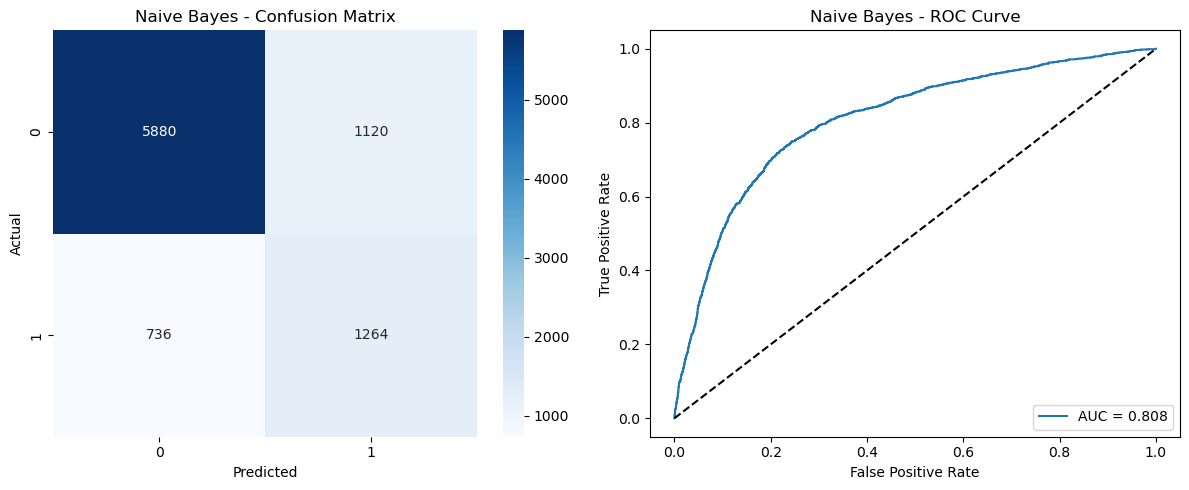

In [45]:
from sklearn.naive_bayes import GaussianNB

print("\n--- Naive Bayes Model ---")

nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred = nb.predict(X_test)
y_prob = nb.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
plot_cm_and_roc(y_test, y_pred, y_prob, "Naive Bayes")


results.append({
    "Model": "Naive Bayes",
    "Accuracy": accuracy_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC_AUC": roc_auc_score(y_test, y_prob)
})

models["Naive Bayes"] = nb



In [46]:
print(results)

[{'Model': 'KNN', 'Accuracy': 0.8277777777777777, 'F1 Score': 0.5545977011494253, 'ROC_AUC': 0.80311575}, {'Model': 'Decision Tree', 'Accuracy': 0.8996666666666666, 'F1 Score': 0.7752053771471247, 'ROC_AUC': 0.8563928571428571}, {'Model': 'Random Forest', 'Accuracy': 0.9368888888888889, 'F1 Score': 0.8482095136290754, 'ROC_AUC': 0.9787648214285714}, {'Model': 'Gradient Boosting', 'Accuracy': 0.9232222222222223, 'F1 Score': 0.8147949611364246, 'ROC_AUC': 0.97195275}, {'Model': 'XGBoost', 'Accuracy': 0.9324444444444444, 'F1 Score': 0.8382118147951038, 'ROC_AUC': 0.9764429285714287}, {'Model': 'Naive Bayes', 'Accuracy': 0.7937777777777778, 'F1 Score': 0.5766423357664233, 'ROC_AUC': 0.8075447142857143}]


#Tuning random forest

In [47]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_grid_rf = {
    "n_estimators": [100, 300, 500, 800],
    "max_depth": [None, 10, 20, 40],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", None]
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_grid_rf,
    n_iter=25,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=1
)

rf_random.fit(X_train, y_train)

print("Best RF Params:", rf_random.best_params_)
print("Best RF ROC-AUC:", rf_random.best_score_)


Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best RF Params: {'n_estimators': 800, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
Best RF ROC-AUC: 0.9758333208515885


In [48]:
best_rf = rf_random.best_estimator_
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

In [49]:
results.append({
    "Model": "Random Forest (Tuned)",
    "Accuracy": accuracy_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC_AUC": roc_auc_score(y_test, y_prob)
})
models["Random Forest (Tuned)"] = best_rf



In [53]:
from sklearn.model_selection import RandomizedSearchCV

from xgboost import XGBClassifier

param_grid_xgb = {
    "n_estimators": [200, 400, 600],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_lambda": [1, 3, 5],
    "reg_alpha": [0, 1, 5],
}

xgb_random = RandomizedSearchCV(
    estimator=XGBClassifier(eval_metric="logloss", random_state=42),
    param_distributions=param_grid_xgb,
    n_iter=25,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=1
)

xgb_random.fit(X_train, y_train)

print("Best XGB Params:", xgb_random.best_params_)
print("Best XGB ROC-AUC:", xgb_random.best_score_)


Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best XGB Params: {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 600, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best XGB ROC-AUC: 0.9777977026868738


In [54]:
best_xgb = xgb_random.best_estimator_

y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:, 1]


In [55]:
results.append({
    "Model": "XGBoost (Tuned)",
    "Accuracy": accuracy_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC_AUC": roc_auc_score(y_test, y_prob)
})
models["XGBoost (Tuned)"] = best_xgb


In [56]:
results_df = pd.DataFrame(results)
print(results_df.sort_values("ROC_AUC", ascending=False))


                   Model  Accuracy  F1 Score   ROC_AUC
7        XGBoost (Tuned)  0.941222  0.862419  0.980784
2          Random Forest  0.936889  0.848210  0.978765
6  Random Forest (Tuned)  0.935333  0.843884  0.978376
4                XGBoost  0.932444  0.838212  0.976443
3      Gradient Boosting  0.923222  0.814795  0.971953
1          Decision Tree  0.899667  0.775205  0.856393
5            Naive Bayes  0.793778  0.576642  0.807545
0                    KNN  0.827778  0.554598  0.803116


In [57]:
best_row = results_df.loc[results_df["ROC_AUC"].idxmax()]
best_model_name = best_row["Model"]
best_model = models[best_model_name]

import joblib
joblib.dump(best_model, "best_loan_model.pkl")

print("Saved:", best_model_name)


Saved: XGBoost (Tuned)


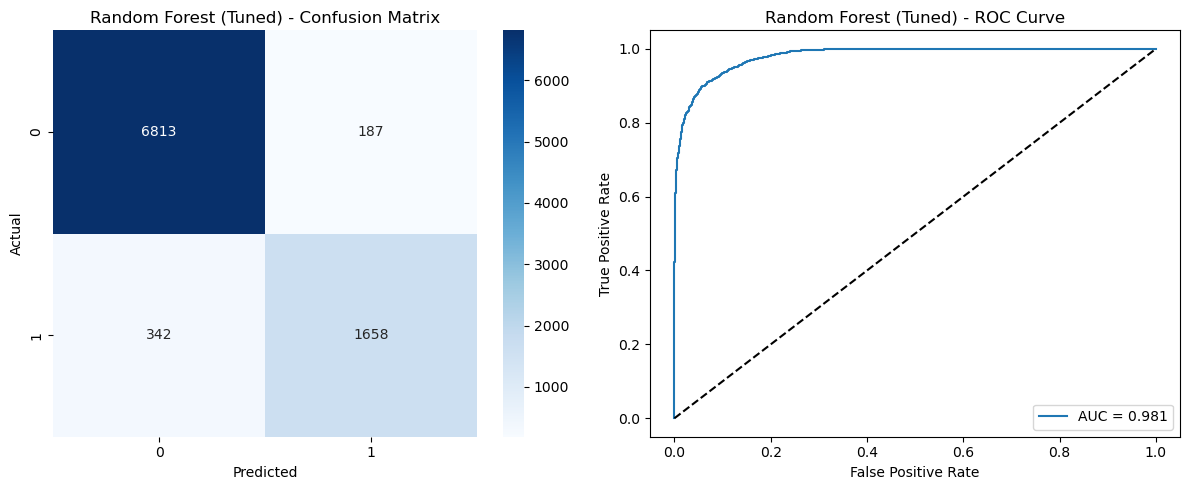

In [58]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

plot_cm_and_roc(y_test, y_pred, y_prob, "Random Forest (Tuned)")
